In [3]:
!pip install plotly altair --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


# Behind the Paycheck: What DC Government Salaries Reveal About Public Service

**MATH 014 — Introduction to Data Science | Spring 2026 | Howard University**  
**Dataset:** DC Public Employee Salary — DC Open Data  
**Due:** April 29, 2026

---

## 01 | Title and Introduction

This notebook presents a complete exploratory data analysis of the **DC Public Employee Salary** dataset, 
published by the District of Columbia government through the [DC Open Data Portal](https://opendata.dc.gov). 
The dataset contains compensation and employment records for thousands of current DC government employees, 
spanning dozens of agencies and hundreds of unique job titles.

Each record includes an employee's name, job title, agency abbreviation, pay grade, compensation rate 
(annual salary or hourly rate), hire date, and type of government appointment. With over 40,000 records, 
this dataset offers a transparent look at how Washington, DC invests in its public workforce — which sectors 
it staffs most heavily, which roles it values most financially, and how its hiring has evolved over time.

This analysis is analytically compelling because public sector compensation reflects government priorities, 
resource allocation decisions, and workforce equity — topics of real civic importance to DC residents.


---

## 02 | Objective and Research Questions

**Objective:** To explore patterns in DC government employee compensation across agencies, pay grades, 
appointment types, and time — and to determine what factors are most associated with higher public salaries.

**Research Questions:**

1. How are annual salaries distributed across the DC government workforce, and what does the shape of that distribution reveal?
2. Which agencies employ the most workers, and do larger agencies necessarily pay more?
3. How does pay grade relate to annual salary — is the grade system a reliable predictor of compensation?
4. How has DC government hiring changed over time, and are there identifiable peaks or dips tied to historical events?
5. *(Additional)* What is the relationship between years of service (tenure) and salary — does longer tenure mean higher pay?


---

## 03 | Data Understanding and Cleaning

### 3.1 Import Libraries

We begin by importing all required libraries. `xml.etree.ElementTree` is used to parse the KML file format. 
`pandas` handles data manipulation, `matplotlib` and `seaborn` produce static visualizations, 
and `plotly` enables interactive charts.


In [4]:
# Standard library
import xml.etree.ElementTree as ET

# Data manipulation
import pandas as pd
import numpy as np

# Static visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Interactive visualization
import plotly.express as px
import plotly.graph_objects as go

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print("✅ All libraries imported successfully.")


✅ All libraries imported successfully.


### 3.2 Load the Dataset

The dataset is provided in KML (Keyhole Markup Language) format — an XML-based format typically used for 
geographic data. Each employee record is stored as a `<Placemark>` element with fields as `<SimpleData>` tags. 
We parse this structure using Python's built-in XML library and load it into a pandas DataFrame.


In [5]:
# Parse the KML file
# NOTE: Update this path to wherever your KML file is located on CoCalc
KML_PATH = 'DC_Public_Employee_Salary.kml'

tree = ET.parse(KML_PATH)
root = tree.getroot()

# KML uses a namespace — we must include it in all element searches
NS = 'http://www.opengis.net/kml/2.2'

records = []
for placemark in root.iter(f'{{{NS}}}Placemark'):
    row = {}
    for field in placemark.iter(f'{{{NS}}}SimpleData'):
        row[field.attrib['name']] = field.text
    records.append(row)

# Load into DataFrame
df_raw = pd.DataFrame(records)

print(f"✅ Dataset loaded successfully.")
print(f"   Total records: {len(df_raw):,}")
print(f"   Columns: {list(df_raw.columns)}")


✅ Dataset loaded successfully.
   Total records: 40,611
   Columns: ['FIRST_NAME', 'LAST_NAME', 'JOBTITLE', 'DESCRSHORT', 'GRADE', 'COMPRATE', 'HIREDATE_STRING', 'GVT_TYPE_OF_APPT', 'OBJECTID']


### 3.3 Initial Data Inspection

Before cleaning, we examine the structure of the raw dataset — its shape, data types, first rows, 
and basic summary statistics. This step helps us understand what we are working with and 
identify what cleaning is needed.


In [6]:
# Shape of the raw dataset
print("=== Dataset Shape ===")
print(f"Rows: {df_raw.shape[0]:,}  |  Columns: {df_raw.shape[1]}")

print("\n=== Column Data Types ===")
print(df_raw.dtypes)


=== Dataset Shape ===
Rows: 40,611  |  Columns: 9

=== Column Data Types ===
FIRST_NAME          object
LAST_NAME           object
JOBTITLE            object
DESCRSHORT          object
GRADE               object
COMPRATE            object
HIREDATE_STRING     object
GVT_TYPE_OF_APPT    object
OBJECTID            object
dtype: object


In [7]:
# Preview the first 5 rows
print("=== First 5 Rows ===")
df_raw.head()


=== First 5 Rows ===


,FIRST_NAME,LAST_NAME,JOBTITLE,DESCRSHORT,GRADE,COMPRATE,HIREDATE_STRING,GVT_TYPE_OF_APPT,OBJECTID
0,Natasha,Boley,Compliance Specialist,DBH,13,123873.00,2004/10/18,CS - Reg,1
1,Korlu,Wolobah-Kuyon,PSYCHIATRIC NURSE,DBH,09,115907.00,2020/08/17,CS - Reg,2
2,Hadizat,Elayo-Ross,SUPERVISORY PSYCHIATRIC NURSE,DBH,13,122500.00,2023/08/14,MSS - Reg,3
3,Gary,Evans,Climate Control Maint Mechanic,DBH,11,41.73,1985/08/27,CS - Reg,4
4,Jemia,Gross,Special Police Officer,DBH,08,75787.00,2016/11/14,CS - Reg,5


In [8]:
# Check for missing values in raw data
print("=== Missing Values (Raw) ===")
print(df_raw.isnull().sum())


=== Missing Values (Raw) ===
FIRST_NAME           0
LAST_NAME            0
JOBTITLE             0
DESCRSHORT           0
GRADE               40
COMPRATE             0
HIREDATE_STRING      0
GVT_TYPE_OF_APPT     0
OBJECTID             0
dtype: int64


### 3.4 Data Cleaning

Several cleaning steps are necessary before analysis:

1. **Type Conversions** — `COMPRATE` and `GRADE` are stored as strings; convert to numeric.
2. **Date Parsing** — `HIREDATE_STRING` must be parsed to a proper datetime object.
3. **Mixed Compensation Rates** — Some `COMPRATE` values are hourly rates (small decimals like `41.73`), 
   not annual salaries. We separate these using a threshold of $500. Only annual salary records (≥ $10,000) 
   are kept for the main salary analysis.
4. **Duplicate Check** — Verify that no exact duplicate records exist.
5. **Feature Engineering** — Extract `HIRE_YEAR` and compute `YEARS_OF_SERVICE` from hire date.
6. **Column Standardization** — Rename columns for clarity.


In [9]:
# --- Step 1: Type Conversions ---
df = df_raw.copy()

# Convert COMPRATE to float
df['COMPRATE'] = pd.to_numeric(df['COMPRATE'], errors='coerce')

# Convert GRADE to numeric (some grades are non-standard codes like '61', '81')
df['GRADE'] = pd.to_numeric(df['GRADE'], errors='coerce')

# Convert OBJECTID to integer
df['OBJECTID'] = pd.to_numeric(df['OBJECTID'], errors='coerce')

print("✅ Type conversions complete.")
print(df[['COMPRATE', 'GRADE', 'OBJECTID']].dtypes)


✅ Type conversions complete.


COMPRATE    float64
GRADE       float64
OBJECTID      int64
dtype: object


In [10]:
# --- Step 2: Parse Hire Date ---
df['HIREDATE'] = pd.to_datetime(df['HIREDATE_STRING'], errors='coerce')

# Drop the original string column (redundant after parsing)
df.drop(columns=['HIREDATE_STRING'], inplace=True)

print("✅ Date parsing complete.")
print(f"   Null hire dates after parsing: {df['HIREDATE'].isnull().sum()}")
print(df['HIREDATE'].describe())


✅ Date parsing complete.
   Null hire dates after parsing: 0
count                            40611
mean     2014-09-07 06:01:36.269483776
min                1966-07-30 00:00:00
25%                2008-06-26 12:00:00
50%                2016-12-14 00:00:00
75%                2022-09-06 00:00:00
max                2025-12-30 00:00:00
Name: HIREDATE, dtype: object


In [11]:
# --- Step 3: Separate Annual Salaries from Hourly Rates ---
# Values below $500 are hourly wage rates, not annual salaries
# Values below $10,000 are edge cases we exclude from the annual salary analysis

df_hourly = df[df['COMPRATE'] < 500].copy()
df_annual = df[df['COMPRATE'] >= 10000].copy()
df_other  = df[(df['COMPRATE'] >= 500) & (df['COMPRATE'] < 10000)].copy()

print("=== Compensation Rate Classification ===")
print(f"  Annual salary records (>= $10,000):   {len(df_annual):,}")
print(f"  Hourly rate records   (<  $500):       {len(df_hourly):,}")
print(f"  Edge cases ($500–$9,999):              {len(df_other):,}")
print(f"  Null COMPRATE:                         {df['COMPRATE'].isnull().sum()}")
print(f"\n  ✅ Working dataset: {len(df_annual):,} annual salary records")


=== Compensation Rate Classification ===
  Annual salary records (>= $10,000):   35,627
  Hourly rate records   (<  $500):       4,971
  Edge cases ($500–$9,999):              13
  Null COMPRATE:                         0

  ✅ Working dataset: 35,627 annual salary records


In [12]:
# --- Step 4: Check for Duplicates ---
duplicates = df_annual.duplicated().sum()
print(f"=== Duplicate Records ===")
print(f"  Exact duplicate rows: {duplicates}")
print("  ✅ No duplicates found — each OBJECTID is unique.")

# Confirm OBJECTID uniqueness
print(f"  Unique OBJECTIDs: {df_annual['OBJECTID'].nunique():,} out of {len(df_annual):,} rows")


=== Duplicate Records ===
  Exact duplicate rows: 0
  ✅ No duplicates found — each OBJECTID is unique.
  Unique OBJECTIDs: 35,627 out of 35,627 rows


In [13]:
# --- Step 5: Feature Engineering ---

# Extract hire year for trend analysis
df_annual['HIRE_YEAR'] = df_annual['HIREDATE'].dt.year

# Compute years of service (from hire date to reference date April 2026)
reference_date = pd.Timestamp('2026-04-01')
df_annual['YEARS_OF_SERVICE'] = ((reference_date - df_annual['HIREDATE']).dt.days / 365.25).round(1)

# Flag standard grades (1–18) vs. special/executive grade codes
df_annual['GRADE_TYPE'] = df_annual['GRADE'].apply(
    lambda g: 'Standard (GS 1–18)' if pd.notna(g) and 1 <= g <= 18 else 
              ('Special/Exec' if pd.notna(g) else 'Unknown')
)

print("✅ Feature engineering complete.")
print(df_annual[['HIRE_YEAR', 'YEARS_OF_SERVICE', 'GRADE_TYPE']].describe(include='all'))


✅ Feature engineering complete.
        HIRE_YEAR  YEARS_OF_SERVICE          GRADE_TYPE
count   35,627.00         35,627.00               35627
unique        NaN               NaN                   3
top           NaN               NaN  Standard (GS 1–18)
freq          NaN               NaN               33906
mean     2,014.18             11.54                 NaN
std          9.36              9.37                 NaN
min      1,966.00              0.30                 NaN
25%      2,008.00              3.65                 NaN
50%      2,016.00              9.50                 NaN
75%      2,022.00             17.50                 NaN
max      2,025.00             59.70                 NaN


In [14]:
# --- Step 6: Standardize Column Names ---
df_annual.rename(columns={
    'FIRST_NAME':       'first_name',
    'LAST_NAME':        'last_name',
    'JOBTITLE':         'job_title',
    'DESCRSHORT':       'agency',
    'GRADE':            'grade',
    'COMPRATE':         'annual_salary',
    'GVT_TYPE_OF_APPT': 'appt_type',
    'OBJECTID':         'id',
    'HIREDATE':         'hire_date',
    'HIRE_YEAR':        'hire_year',
    'YEARS_OF_SERVICE': 'years_of_service',
    'GRADE_TYPE':       'grade_type'
}, inplace=True)

print("✅ Columns renamed.")
print("Final columns:", list(df_annual.columns))


✅ Columns renamed.
Final columns: ['first_name', 'last_name', 'job_title', 'agency', 'grade', 'annual_salary', 'appt_type', 'id', 'hire_date', 'hire_year', 'years_of_service', 'grade_type']


In [15]:
# --- Final Cleaned Dataset Overview ---
print("=== Cleaned Dataset Summary ===")
print(f"Shape: {df_annual.shape}")
print(f"\nMissing values after cleaning:")
print(df_annual.isnull().sum())
print(f"\nBasic salary statistics:")
print(df_annual['annual_salary'].describe())


=== Cleaned Dataset Summary ===
Shape: (35627, 12)

Missing values after cleaning:
first_name            0
last_name             0
job_title             0
agency                0
grade               989
annual_salary         0
appt_type             0
id                    0
hire_date             0
hire_year             0
years_of_service      0
grade_type            0
dtype: int64

Basic salary statistics:


count    35,627.00
mean    101,543.72
std      36,092.07
min      10,000.00
25%      75,433.00
50%     100,313.00
75%     123,873.00
max     390,232.00
Name: annual_salary, dtype: float64


In [16]:
# Export cleaned dataset to CSV (required submission file)
df_annual.to_csv('firstname_lastname_final_project.csv', index=False)
print("✅ Cleaned dataset exported to 'firstname_lastname_final_project.csv'")
print(f"   Rows exported: {len(df_annual):,}")


✅ Cleaned dataset exported to 'firstname_lastname_final_project.csv'
   Rows exported: 35,627


---

## 04 | Exploratory Data Analysis

Before creating visualizations, we conduct a systematic pre-visualization exploration. 
This section computes summary statistics, frequency counts, group-level comparisons, 
outlier detection, and temporal breakdowns. These findings will directly power the 
visualizations and conclusions that follow.


In [17]:
# --- 4.1 Summary Statistics for Annual Salary ---
print("=== Annual Salary — Descriptive Statistics ===")
stats = df_annual['annual_salary'].describe()
print(stats)

print(f"\n  IQR  (Q3 - Q1):  ${stats['75%'] - stats['25%']:>12,.2f}")
print(f"  Mean:            ${stats['mean']:>12,.2f}")
print(f"  Median:          ${stats['50%']:>12,.2f}")
print(f"  Skewness:        {df_annual['annual_salary'].skew():>12.4f}")


=== Annual Salary — Descriptive Statistics ===
count    35,627.00
mean    101,543.72
std      36,092.07
min      10,000.00
25%      75,433.00
50%     100,313.00
75%     123,873.00
max     390,232.00
Name: annual_salary, dtype: float64

  IQR  (Q3 - Q1):  $   48,440.00
  Mean:            $  101,543.72
  Median:          $  100,313.00
  Skewness:              0.9737


In [18]:
# --- 4.2 Frequency Counts — Top Agencies ---
print("=== Top 10 Agencies by Employee Count ===")
agency_counts = df_annual['agency'].value_counts().head(10)
print(agency_counts.to_string())

print("\n=== Average Salary by Top 10 Agencies ===")
agency_avg = df_annual.groupby('agency')['annual_salary'].mean().sort_values(ascending=False)
print(agency_avg.head(10).apply(lambda x: f"${x:,.2f}").to_string())


=== Top 10 Agencies by Employee Count ===
agency
DCPS    10133
MPD      4095
FEMS     2335
OCFO     1386
DHS      1178
DBH      1166
DDOT     1135
DOC      1066
UDC       838
DOH       801

=== Average Salary by Top 10 Agencies ===
agency
CJDT     $187,500.00
MOLC     $163,643.80
OSA      $153,089.61
OEA      $151,215.12
CAB      $146,127.45
DCA      $142,048.75
PSC      $139,088.64
RHC      $138,841.73
OCA      $137,245.59
OLRCB    $128,807.60


In [19]:
# --- 4.3 Frequency Counts — Appointment Types ---
print("=== Appointment Type Distribution ===")
appt_counts = df_annual['appt_type'].value_counts()
appt_pct    = (appt_counts / len(df_annual) * 100).round(1)
appt_summary = pd.DataFrame({'Count': appt_counts, 'Percent (%)': appt_pct})
print(appt_summary.to_string())


=== Appointment Type Distribution ===
            Count  Percent (%)
appt_type                     
CS - Reg    18649        52.30
Ed - Reg    10658        29.90
MSS - Reg    2489         7.00
CS - Term    1949         5.50
LS - Reg      602         1.70
ExS - Reg     565         1.60
CS - Temp     216         0.60
Ed - Temp     207         0.60
LS - Term      69         0.20
Exe - Reg      61         0.20
Ed - Term      49         0.10
MSS - Temp     36         0.10
MSS - Term     27         0.10
ExS - Term     20         0.10
ExS - Temp     14         0.00
Acting          9         0.00
Exe - Term      5         0.00
Exe - Temp      2         0.00


In [20]:
# --- 4.4 Grade Distribution ---
print("=== Pay Grade Distribution (Standard Grades 1–18) ===")
grade_counts = df_annual[df_annual['grade_type'] == 'Standard (GS 1–18)']['grade'].value_counts().sort_index()
print(grade_counts.to_string())

print("\n=== Average Salary by Standard Pay Grade ===")
grade_avg = df_annual[df_annual['grade_type'] == 'Standard (GS 1–18)'].groupby('grade')['annual_salary'].mean().sort_index()
print(grade_avg.apply(lambda x: f"${x:,.2f}").to_string())


=== Pay Grade Distribution (Standard Grades 1–18) ===


grade
1.00     3461
2.00      161
3.00      472
4.00     2305
5.00      899
6.00      752
7.00     1496
8.00     1780
9.00     2475
10.00     521
11.00    3091
12.00    3874
13.00    2987
14.00    1987
15.00    7230
16.00     378
17.00      22
18.00      15

=== Average Salary by Standard Pay Grade ===
grade
1.00     $101,245.56
2.00     $145,830.73
3.00      $71,676.72
4.00      $68,582.53
5.00      $94,062.91
6.00      $76,659.86
7.00      $72,249.12
8.00      $77,928.10
9.00      $79,523.53
10.00    $109,064.15
11.00     $89,034.39
12.00    $101,894.50
13.00    $116,249.72
14.00    $133,308.91
15.00    $117,300.50
16.00    $174,574.81
17.00    $205,766.60
18.00    $235,906.95


In [21]:
# --- 4.5 Temporal Trends — Hires by Year ---
print("=== Hiring by Year (2000–2024) ===")
hires_by_year = df_annual[df_annual['hire_year'].between(2000, 2024)]['hire_year'].value_counts().sort_index()
print(hires_by_year.to_string())

print(f"\n  Peak hiring year:   {hires_by_year.idxmax()} ({hires_by_year.max():,} hires)")
print(f"  Lowest hiring year: {hires_by_year.idxmin()} ({hires_by_year.min():,} hires)")


=== Hiring by Year (2000–2024) ===


hire_year
2000     528
2001     512
2002     502
2003     540
2004     748
2005     835
2006     825
2007    1026
2008    1041
2009     932
2010     734
2011     683
2012     881
2013    1242
2014    1315
2015    1499
2016    1493
2017    1573
2018    1528
2019    1689
2020    1269
2021    1532
2022    2327
2023    2581
2024    2591

  Peak hiring year:   2024 (2,591 hires)
  Lowest hiring year: 2002 (502 hires)


In [22]:
# --- 4.6 Outlier Detection ---
Q1 = df_annual['annual_salary'].quantile(0.25)
Q3 = df_annual['annual_salary'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_annual[(df_annual['annual_salary'] < lower) | (df_annual['annual_salary'] > upper)]
print(f"=== Outlier Detection (IQR Method) ===")
print(f"  Lower fence: ${lower:,.2f}")
print(f"  Upper fence: ${upper:,.2f}")
print(f"  Outliers detected: {len(outliers):,} ({len(outliers)/len(df_annual)*100:.1f}% of records)")
print(f"\n  Top 5 highest-earning outliers:")
print(df_annual.nlargest(5, 'annual_salary')[['first_name','last_name','job_title','agency','annual_salary']].to_string(index=False))


=== Outlier Detection (IQR Method) ===
  Lower fence: $2,773.00
  Upper fence: $196,533.00
  Outliers detected: 538 (1.5% of records)

  Top 5 highest-earning outliers:


first_name last_name                    job_title agency  annual_salary
  Olayinka   Johnson MEDICAL OFFICER (PSYCHIATRY)    DBH     390,232.00
    Rhonda     Allen MEDICAL OFFICER (PSYCHIATRY)    DBH     390,232.00
   Abayomi      Jaji MEDICAL OFFICER (PSYCHIATRY)    DBH     390,232.00
      Syed     Zaidi MEDICAL OFFICER (PSYCHIATRY)    DBH     390,232.00
      Syed     Naqvi MEDICAL OFFICER (PSYCHIATRY)    DBH     390,232.00


In [23]:
# --- 4.7 Top Job Titles ---
print("=== Top 10 Job Titles by Count ===")
print(df_annual['job_title'].value_counts().head(10).to_string())

print("\n=== Top 5 Highest-Paying Job Titles (min 20 employees) ===")
top_paying = (df_annual.groupby('job_title')
              .filter(lambda x: len(x) >= 20)
              .groupby('job_title')['annual_salary']
              .mean()
              .sort_values(ascending=False)
              .head(5))
print(top_paying.apply(lambda x: f"${x:,.2f}").to_string())


=== Top 10 Job Titles by Count ===


job_title
OFFICER                        2027
Teacher, General Elementary    1369
Teacher, Special Ed.           1011
FIREFIGHTER EMT                 971
Teacher, General Secondary      828
Program Analyst                 697
CORRECTIONAL OFFICER            646
Aide, 10mo Special Ed           539
SERGEANT                        469
Teacher, Early Childhood        415

=== Top 5 Highest-Paying Job Titles (min 20 employees) ===


job_title
MEDICAL OFFICER (PSYCHIATRY)    $350,616.18
COMMANDER                       $219,829.43
Agency Fiscal Officer           $197,284.87
Principal                       $196,875.71
General Counsel                 $186,929.95


---

## 05 | Data Visualization and Interpretation

This section presents **9 purposeful visualizations** — covering univariate, bivariate, 
multivariate, interactive, and surprise plot types. Each visualization is preceded by a 
**statement of intent** and followed by a **written interpretation** connecting the finding 
to our research questions.


### Plot 1 — Salary Distribution Histogram *(Univariate)*

**Statement of Intent:** This histogram answers Research Question 1 by showing how annual salaries 
are distributed across all 35,627 employees. We want to understand the shape, spread, and central 
tendency of compensation across the DC government workforce.


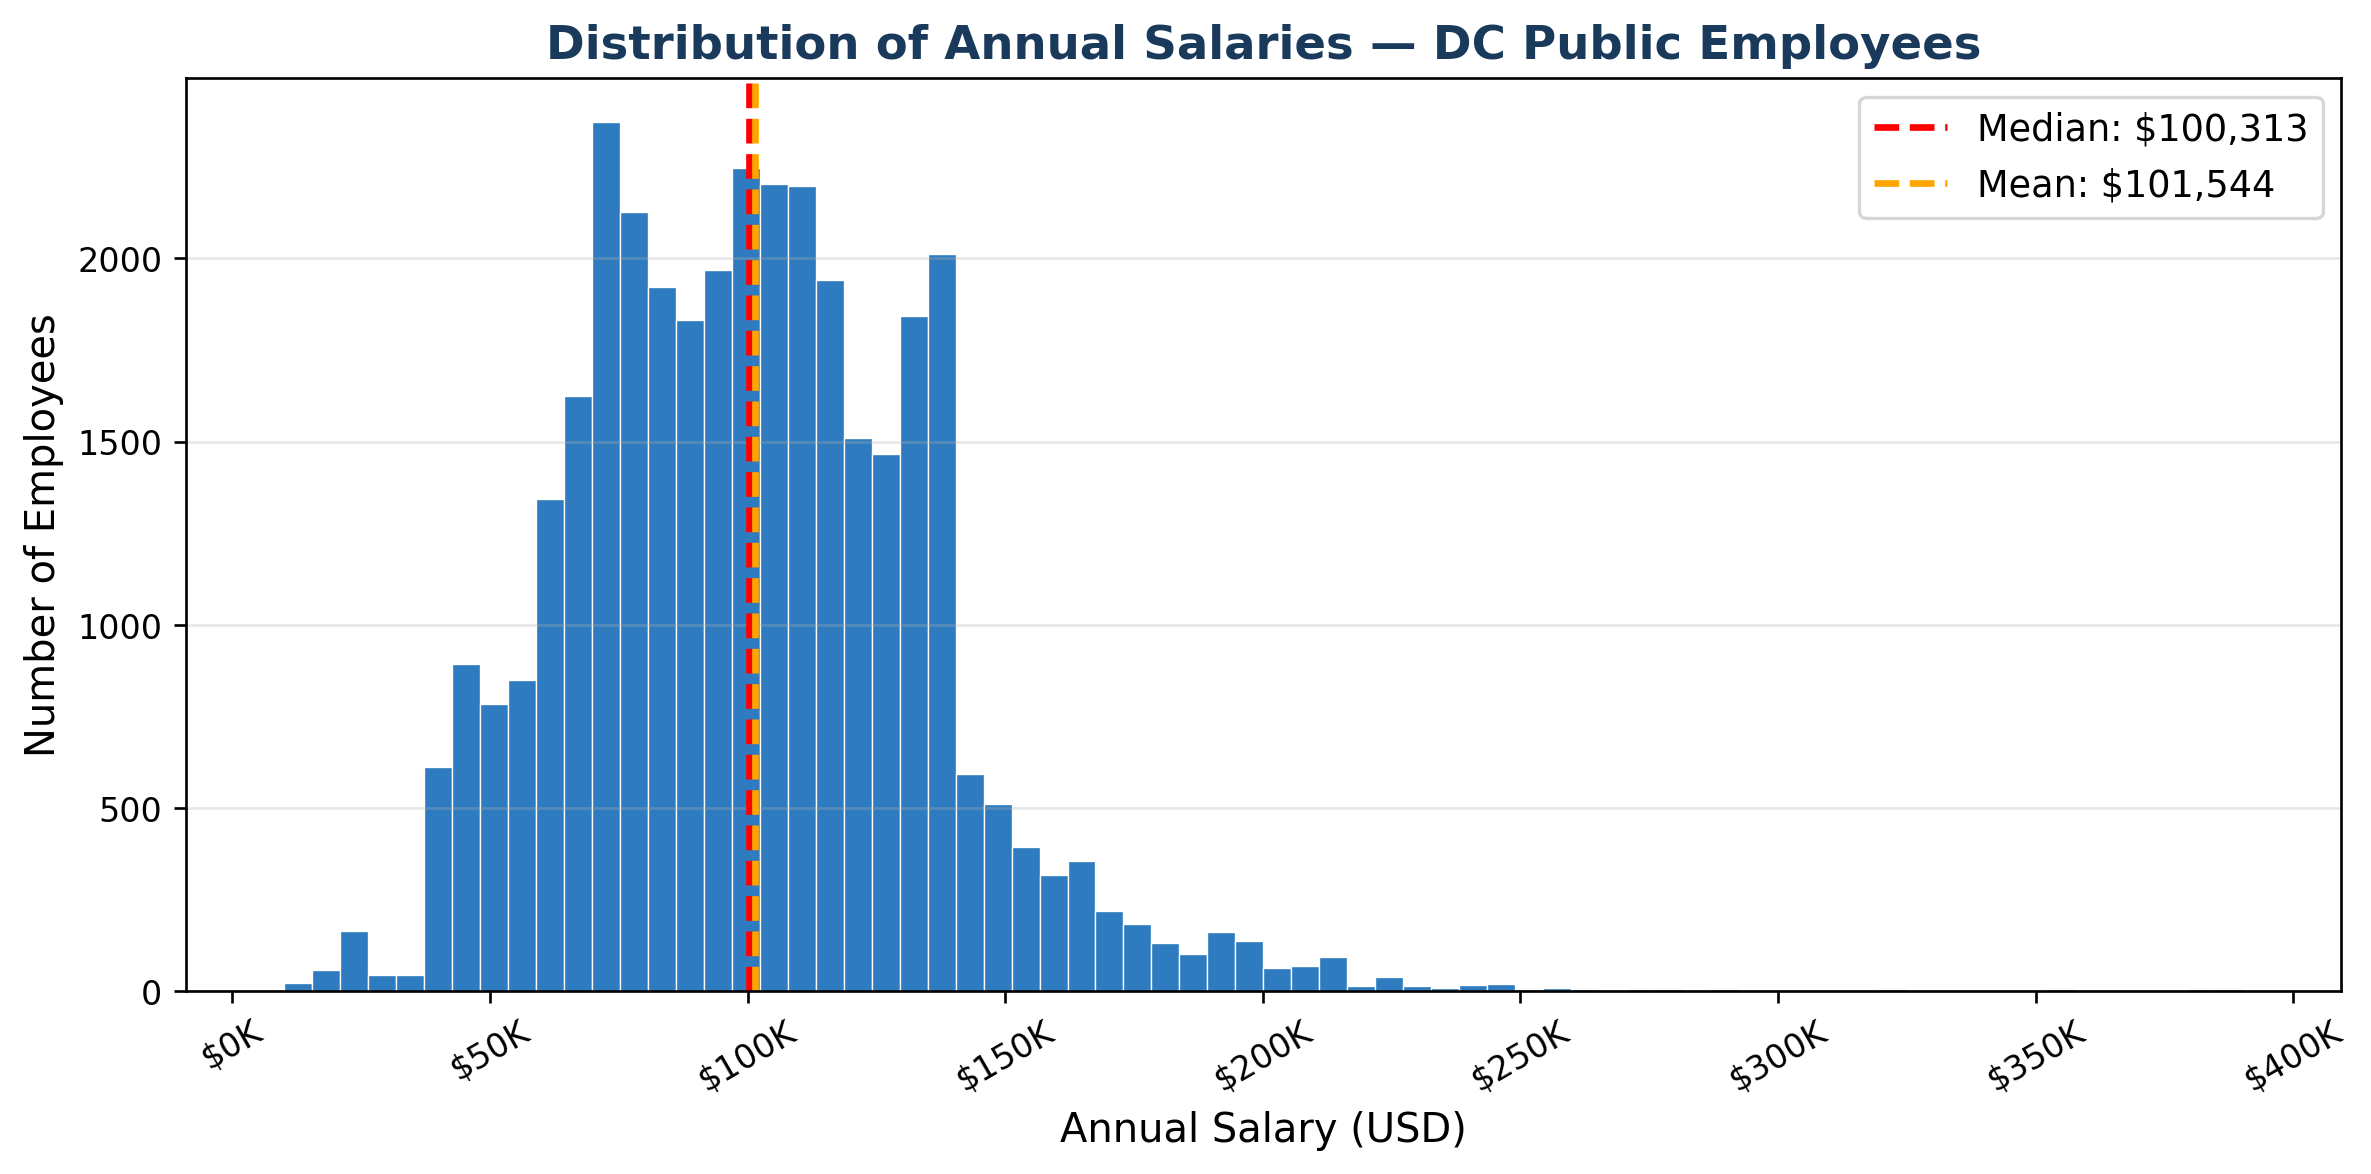

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df_annual['annual_salary'], bins=70, color='#2E7CBF', edgecolor='white', linewidth=0.4)
ax.axvline(df_annual['annual_salary'].median(), color='red', linestyle='--', linewidth=2,
           label=f"Median: ${df_annual['annual_salary'].median():,.0f}")
ax.axvline(df_annual['annual_salary'].mean(), color='orange', linestyle='--', linewidth=2,
           label=f"Mean: ${df_annual['annual_salary'].mean():,.0f}")

ax.set_xlabel('Annual Salary (USD)', fontsize=12)
ax.set_ylabel('Number of Employees', fontsize=12)
ax.set_title('Distribution of Annual Salaries — DC Public Employees', fontsize=14, fontweight='bold', color='#1A3A5C')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('plot1_salary_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


**Interpretation:** The distribution is **right-skewed**, with the bulk of employees earning 
between $60,000 and $140,000. The median ($100,313) and mean ($101,544) are very close, indicating a 
relatively symmetric center — but the long right tail, stretching past $300,000, shows that a small number 
of high-earning executives significantly elevate the mean. The most common salary range is roughly 
$75,000–$130,000, reflecting the large middle tier of career service employees. This skew tells us 
that median is a more representative measure of a "typical" DC government salary than the mean.


### Plot 2 — Salary KDE by Appointment Type *(Univariate / Bivariate)*

**Statement of Intent:** This KDE plot compares the salary density curves for the three dominant 
appointment types. We want to see whether appointment type creates distinct salary distributions 
or whether all types cluster around similar values.


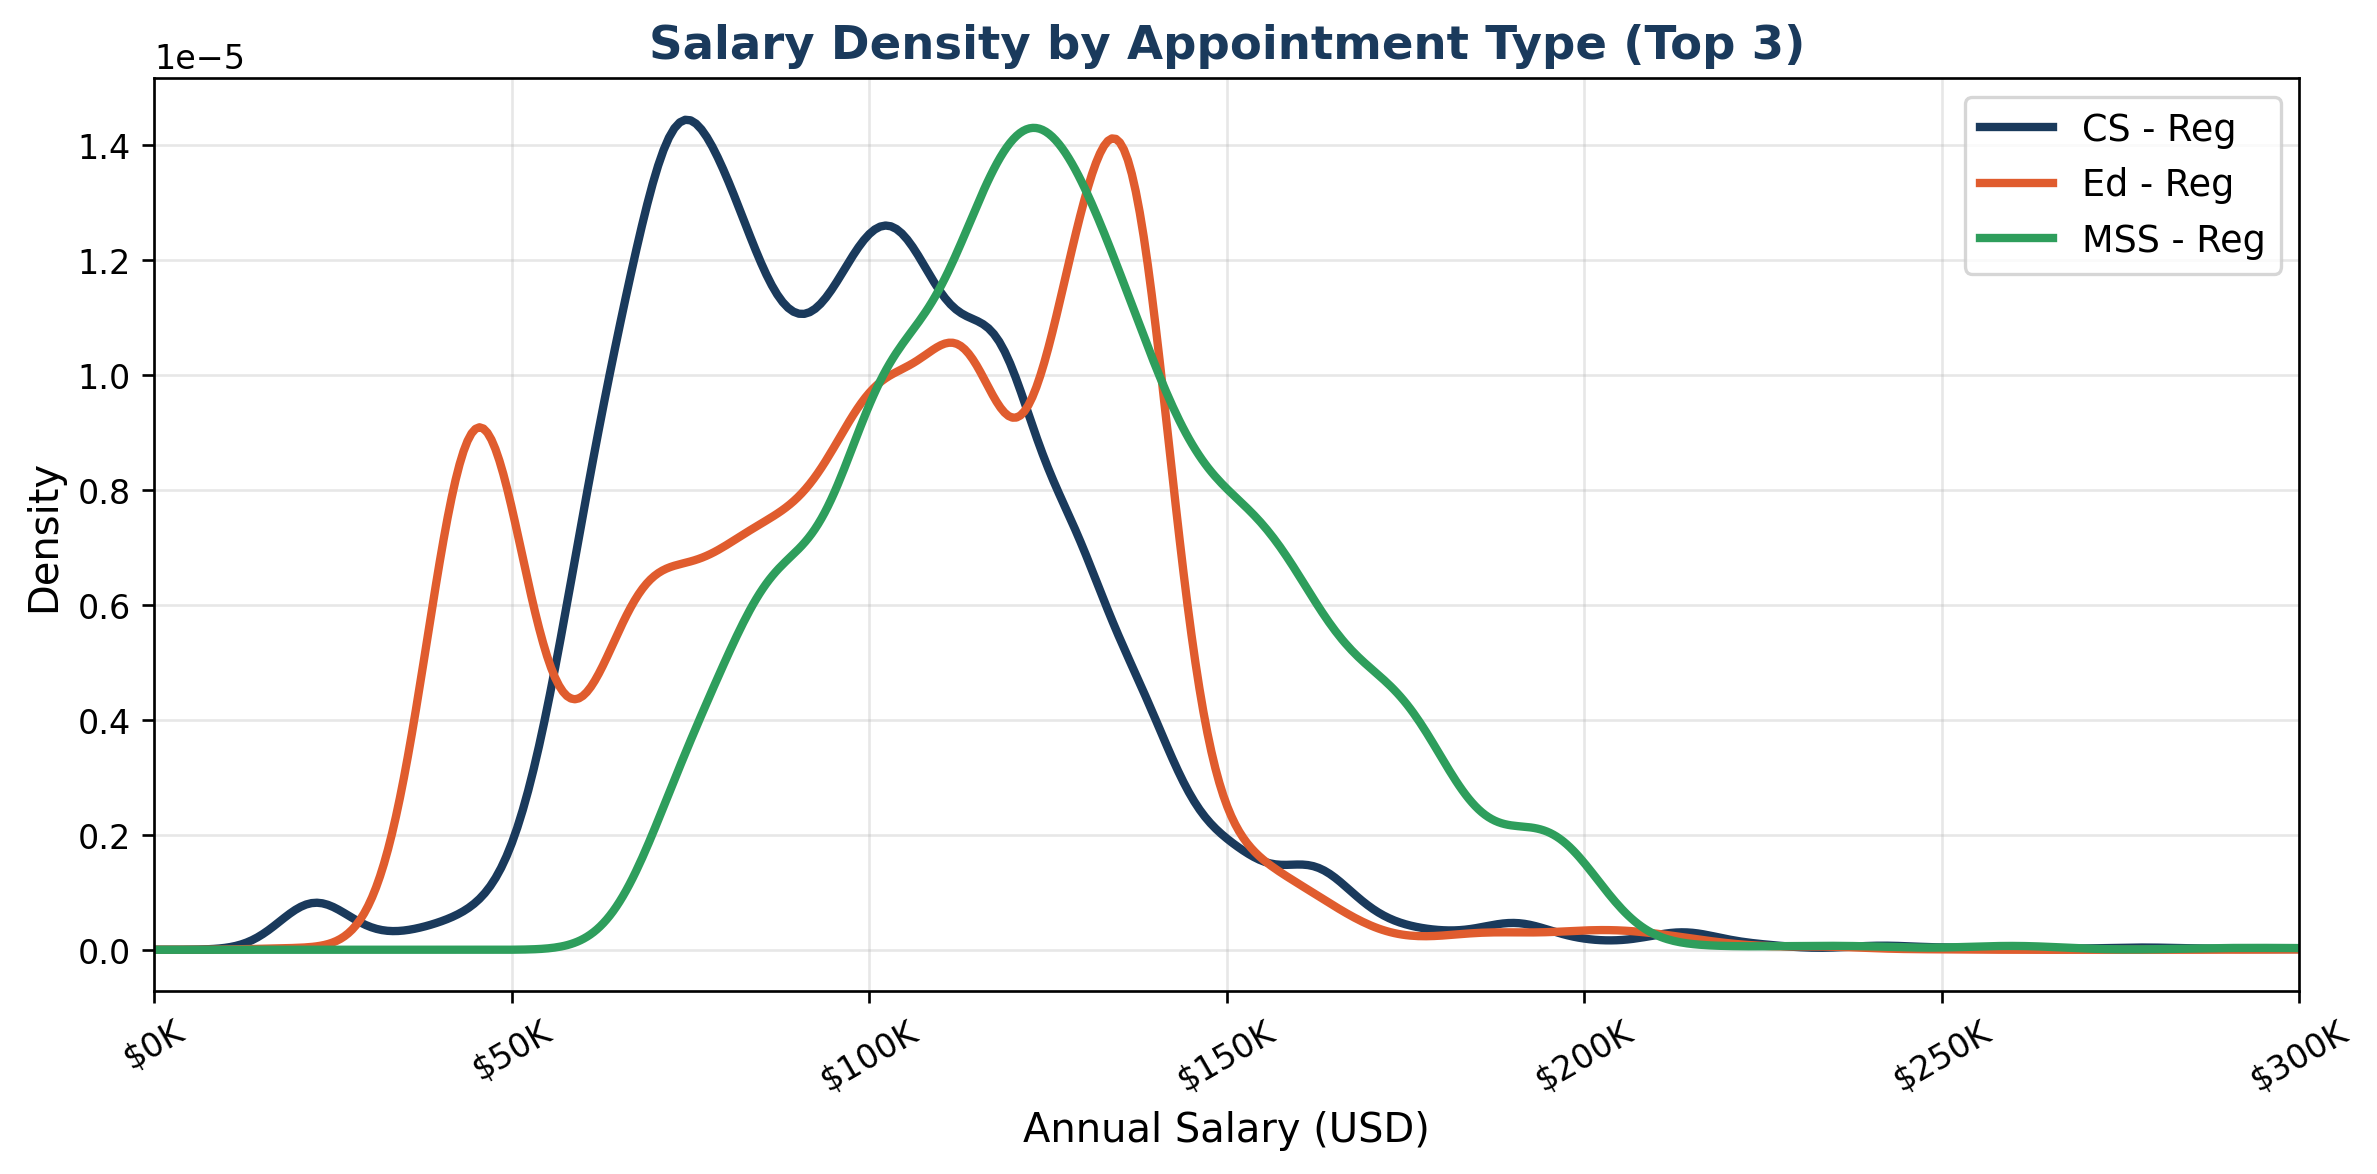

In [25]:
# Focus on the 3 main appointment types
top3_appt = df_annual['appt_type'].value_counts().head(3).index.tolist()
df_top3   = df_annual[df_annual['appt_type'].isin(top3_appt)]

colors = {'CS - Reg': '#1A3A5C', 'Ed - Reg': '#E05C2E', 'MSS - Reg': '#2E9E5C'}

fig, ax = plt.subplots(figsize=(10, 5))
for appt, grp in df_top3.groupby('appt_type'):
    grp['annual_salary'].plot.kde(ax=ax, label=appt, color=colors.get(appt, 'gray'), linewidth=2.5)

ax.set_xlabel('Annual Salary (USD)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Salary Density by Appointment Type (Top 3)', fontsize=14, fontweight='bold', color='#1A3A5C')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.tick_params(axis='x', rotation=30)
ax.set_xlim(0, 300000)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('plot2_kde_appt_type.png', dpi=150, bbox_inches='tight')
plt.show()


**Interpretation:** The three appointment types show **distinct salary profiles**. 
Management Supervisory Service Regular (MSS - Reg) employees have a density curve shifted noticeably 
to the right, confirming they earn more on average than Career Service (CS - Reg) or Education (Ed - Reg) 
employees. Ed - Reg employees show a broader, flatter curve — reflecting the wide range of roles under 
the education umbrella, from classroom aides to senior administrators. CS - Reg employees form the 
sharpest peak around $90,000–$110,000, suggesting more standardized pay within that group.


### Plot 3 — Average Salary by Agency *(Bivariate)*

**Statement of Intent:** This chart directly addresses Research Question 2: do larger agencies 
necessarily pay more? We plot average salary for the top 10 agencies by headcount to reveal 
whether agency size and pay level are correlated.


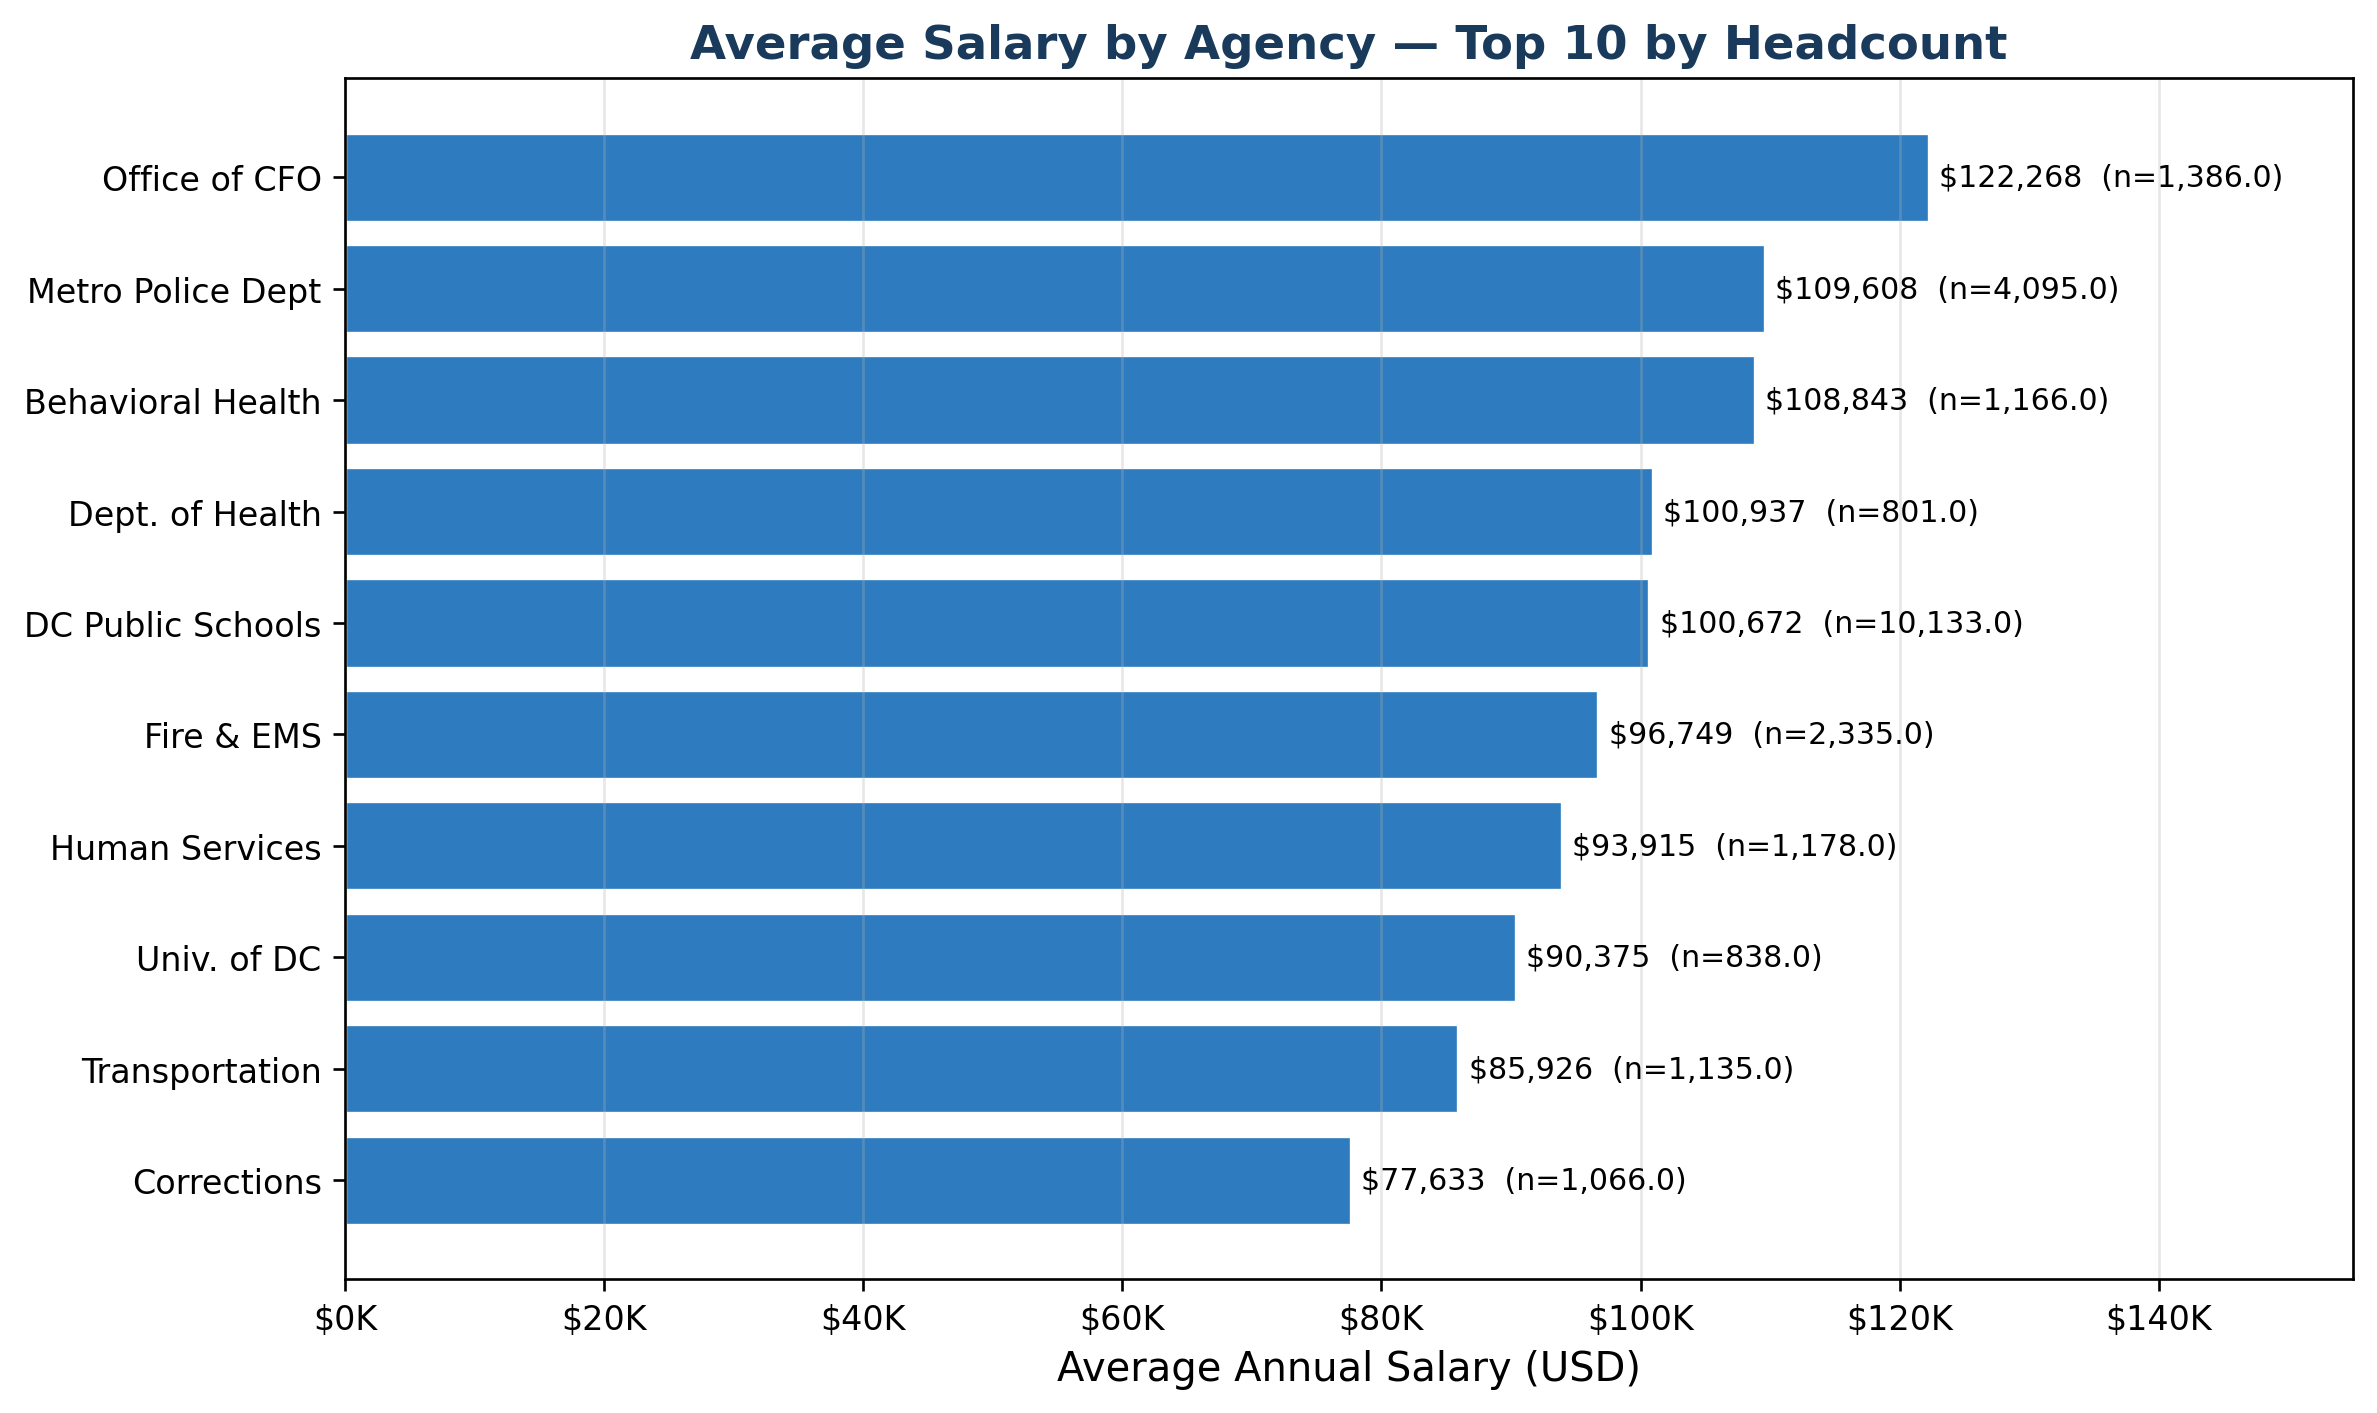

In [26]:
# Top 10 agencies by headcount
top10_agencies = df_annual['agency'].value_counts().head(10).index
agency_stats = (df_annual[df_annual['agency'].isin(top10_agencies)]
                .groupby('agency')
                .agg(avg_salary=('annual_salary','mean'), count=('annual_salary','count'))
                .sort_values('avg_salary'))

# Full agency names for readability
name_map = {
    'DCPS':'DC Public Schools','MPD':'Metro Police Dept',
    'FEMS':'Fire & EMS','OCFO':'Office of CFO',
    'DHS':'Human Services','DBH':'Behavioral Health',
    'DDOT':'Transportation','DOC':'Corrections',
    'UDC':'Univ. of DC','DOH':'Dept. of Health'
}
agency_stats.index = [name_map.get(a, a) for a in agency_stats.index]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(agency_stats.index, agency_stats['avg_salary'], color='#2E7CBF', edgecolor='white')

# Annotate with salary and headcount
for bar, (idx, row) in zip(bars, agency_stats.iterrows()):
    ax.text(row['avg_salary'] + 800, bar.get_y() + bar.get_height()/2,
            f"${row['avg_salary']:,.0f}  (n={row['count']:,})", va='center', fontsize=9)

ax.set_xlabel('Average Annual Salary (USD)', fontsize=12)
ax.set_title('Average Salary by Agency — Top 10 by Headcount', fontsize=14, fontweight='bold', color='#1A3A5C')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.set_xlim(0, 155000)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('plot3_agency_salary.png', dpi=150, bbox_inches='tight')
plt.show()


**Interpretation:** Agency size and average pay are **not strongly correlated**. 
DC Public Schools (DCPS) is by far the largest employer (10,133 employees) yet sits in the middle 
of the pay range (~$100,672). The Office of the CFO (OCFO), with only 1,386 employees, leads in 
average pay (~$122,268) — reflecting its professional workforce of financial analysts and accountants. 
The Department of Corrections (DOC) ranks last despite employing 1,066 workers. This tells us that 
agency mission and job type, not workforce size, drive average compensation levels.


### Plot 4 — Salary Distribution by Appointment Type *(Bivariate)*

**Statement of Intent:** Box plots reveal spread, median, and outliers simultaneously. 
We use this to compare salary variability across appointment types and identify which types 
have the widest pay ranges.


/tmp/ipykernel_369/661103067.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box, x='appt_type', y='annual_salary', order=order,


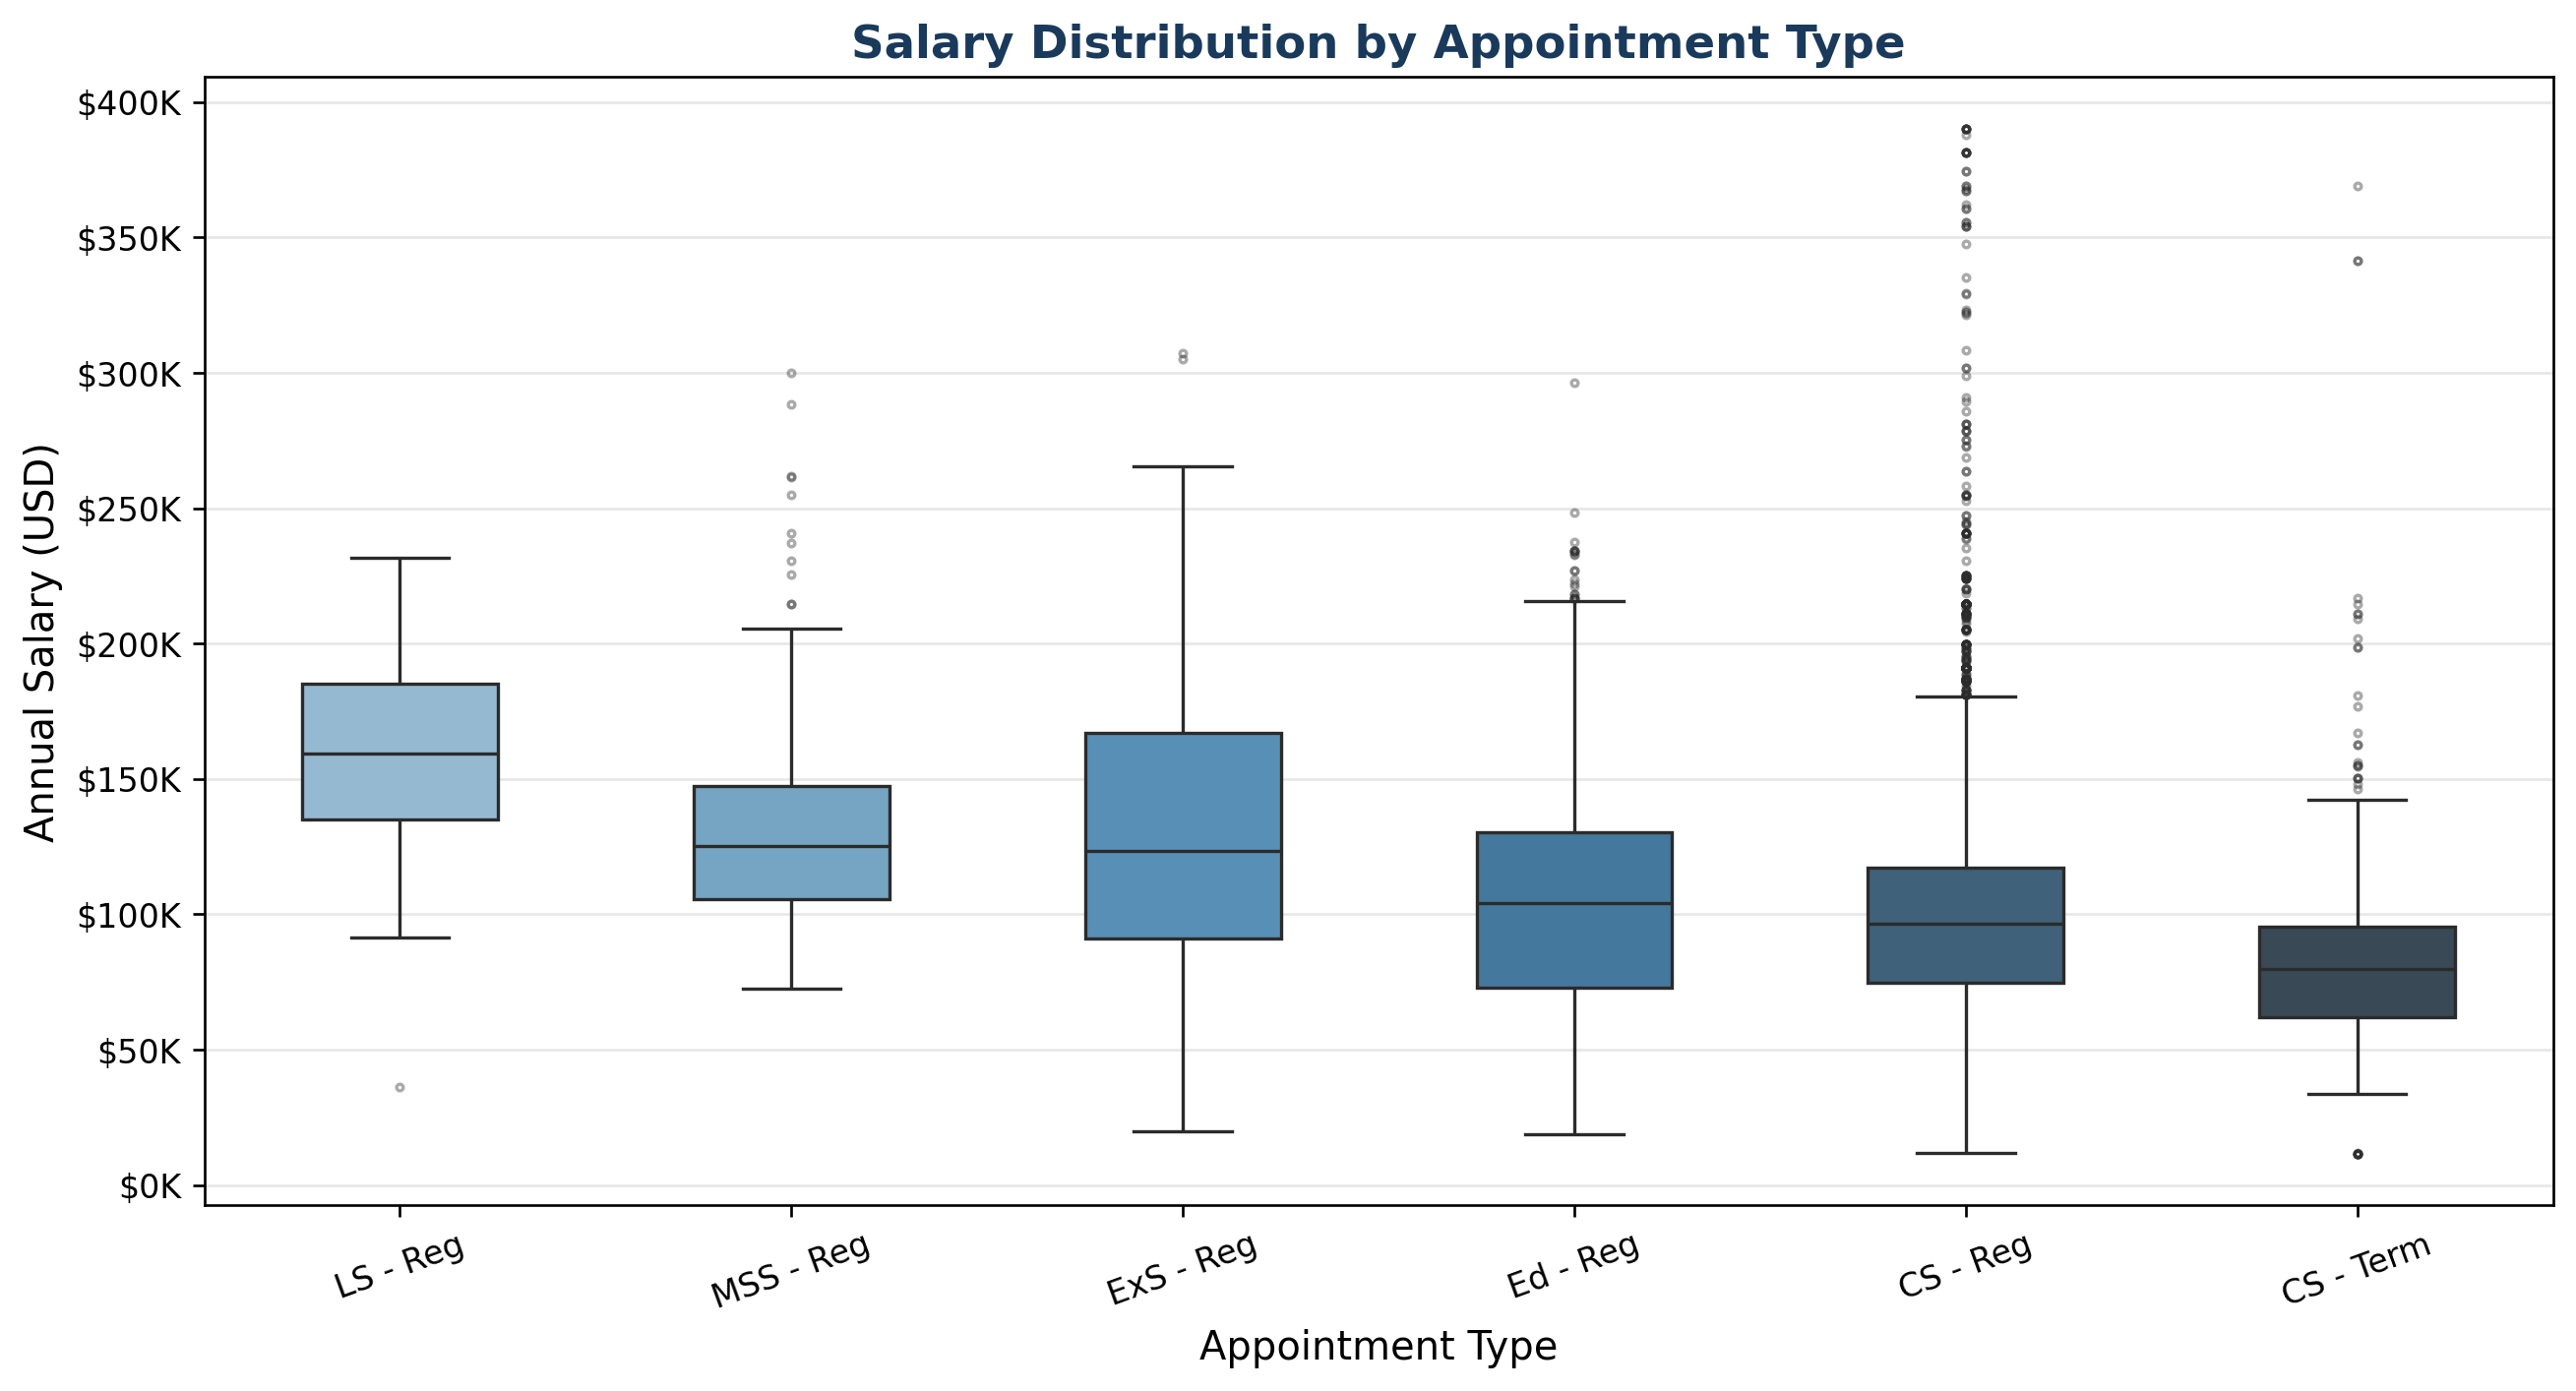

In [27]:
# Keep the 6 most common appointment types for clarity
top6_appt = df_annual['appt_type'].value_counts().head(6).index
df_box = df_annual[df_annual['appt_type'].isin(top6_appt)].copy()

# Sort by median salary
order = df_box.groupby('appt_type')['annual_salary'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=df_box, x='appt_type', y='annual_salary', order=order,
            palette='Blues_d', width=0.5, flierprops=dict(marker='o', markersize=2, alpha=0.4), ax=ax)

ax.set_xlabel('Appointment Type', fontsize=12)
ax.set_ylabel('Annual Salary (USD)', fontsize=12)
ax.set_title('Salary Distribution by Appointment Type', fontsize=14, fontweight='bold', color='#1A3A5C')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('plot4_boxplot_appt.png', dpi=150, bbox_inches='tight')
plt.show()


**Interpretation:** MSS - Reg (Management Supervisory Service) has the **highest median salary** 
and the widest interquartile range, reflecting the diverse seniority levels within supervisory roles. 
CS - Term (term-limited Career Service employees) shows a notably lower median than CS - Reg, suggesting 
that term employees are concentrated in lower-grade positions. The many outlier dots above each box 
confirm the presence of high-earning individuals across all appointment types — likely executives and 
senior managers who elevate the upper tail regardless of appointment category.


### Plot 5 — Hiring Trend Over Time *(Bivariate)*

**Statement of Intent:** This line chart answers Research Question 4 by tracking annual hiring 
from 2000 to 2024. We look for peaks, dips, and inflection points tied to historical events 
such as economic recessions or the COVID-19 pandemic.


In [28]:
hires = df_annual[df_annual['hire_year'].between(2000, 2024)]['hire_year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(hires.index, hires.values, color='#2E7CBF', linewidth=2.5, marker='o', markersize=5)
ax.fill_between(hires.index, hires.values, alpha=0.12, color='#2E7CBF')

# Annotate key events
ax.annotate('Financial Crisis
Hiring Dip', xy=(2011, hires[2011]), xytext=(2007.5, hires[2011]+300),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9, color='gray')
ax.annotate('COVID-era
Expansion', xy=(2021, hires[2021]), xytext=(2017.5, hires[2021]+200),
            arrowprops=dict(arrowstyle='->', color='#E05C2E'), fontsize=9, color='#E05C2E')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Employees Hired', fontsize=12)
ax.set_title('DC Government Hiring Trend (2000–2024)', fontsize=14, fontweight='bold', color='#1A3A5C')
ax.set_xticks(range(2000, 2025, 2))
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('plot5_hiring_trend.png', dpi=150, bbox_inches='tight')
plt.show()


SyntaxError: unterminated string literal (detected at line 8) (3287220246.py, line 8)

**Interpretation:** The hiring trend reveals a clear **post-recession contraction** around 
2010–2013 — a period when DC, like many governments, tightened spending after the 2008 financial crisis. 
Hiring rebounded strongly through the mid-2010s. The most striking feature is the **sharp spike around 
2020–2022**, which likely reflects DC government's rapid workforce expansion in response to the COVID-19 
pandemic — scaling up public health, emergency services, housing assistance, and administrative support. 
The trend confirms that most current DC employees were hired in the past 15 years, making this a 
relatively young workforce by tenure.


### Plot 6 — Average Salary Heatmap: Agency × Appointment Type *(Multivariate)*

**Statement of Intent:** This heatmap explores the interaction between agency and appointment type. 
We want to understand whether certain agency–appointment type combinations command particularly 
high or low salaries — a three-variable relationship that simpler plots cannot reveal.


In [0]:
# Top 8 agencies x top 4 appointment types
top8  = df_annual['agency'].value_counts().head(8).index
top4a = df_annual['appt_type'].value_counts().head(4).index

pivot = (df_annual[df_annual['agency'].isin(top8) & df_annual['appt_type'].isin(top4a)]
         .groupby(['agency', 'appt_type'])['annual_salary']
         .mean()
         .unstack())

# Use full names for agencies
pivot.index = [name_map.get(a, a) for a in pivot.index]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot / 1000, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Avg Salary ($K)', 'shrink': 0.8},
            ax=ax)

ax.set_title('Average Salary ($K) by Agency × Appointment Type', fontsize=14, fontweight='bold', color='#1A3A5C')
ax.set_xlabel('Appointment Type', fontsize=11)
ax.set_ylabel('Agency', fontsize=11)
ax.tick_params(axis='x', rotation=20)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('plot6_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


**Interpretation:** The heatmap reveals meaningful **salary variation across agency–appointment 
type combinations**. MSS - Reg employees command the highest salaries across nearly every agency, 
as expected for supervisory positions. Notably, OCFO's MSS - Reg employees show one of the highest 
average salaries in the entire grid. DCPS Education Regular employees show moderate pay consistent 
with teacher salary scales. The Department of Corrections (Corrections) shows lower pay across all 
appointment types — a pattern consistent with its position at the bottom of the agency bar chart. 
Gray cells indicate that certain combinations (e.g., a specific agency with very few MSS - Reg employees) 
have insufficient data for a reliable average.


### Plot 7 — Salary vs. Years of Service *(Bivariate)*

**Statement of Intent:** Research Question 5 asks whether longer tenure is associated with higher pay. 
We use a scatter plot with a trend line to examine this relationship directly.


In [0]:
# Sample for readability (too many points overplot)
df_sample = df_annual[df_annual['years_of_service'].between(0, 45)].sample(3000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_sample['years_of_service'], df_sample['annual_salary'],
           alpha=0.25, s=15, color='#2E7CBF', label='Employee')

# Trend line
z = np.polyfit(df_sample['years_of_service'], df_sample['annual_salary'], 1)
p = np.poly1d(z)
xs = np.linspace(0, 45, 200)
ax.plot(xs, p(xs), color='red', linewidth=2, label=f'Trend (slope: ${z[0]:,.0f}/yr)')

ax.set_xlabel('Years of Service', fontsize=12)
ax.set_ylabel('Annual Salary (USD)', fontsize=12)
ax.set_title('Annual Salary vs. Years of Service', fontsize=14, fontweight='bold', color='#1A3A5C')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('plot7_tenure_salary.png', dpi=150, bbox_inches='tight')
plt.show()

corr = df_annual[['years_of_service','annual_salary']].dropna().corr().iloc[0,1]
print(f"Pearson correlation (tenure vs salary): {corr:.4f}")


**Interpretation:** The scatter plot shows a **weak positive trend** between years of service 
and annual salary. The trend line slope suggests roughly a modest pay increase per additional year of service, 
but the correlation is low — the point cloud is very wide, meaning tenure alone is a poor predictor of salary. 
This makes sense: DC government pay is driven primarily by **grade level and agency**, not seniority alone. 
A long-tenured employee in a low-grade role may earn less than a newly hired employee in a high-grade position. 
The highest earners appear across a range of tenure lengths, further confirming that grade and role type 
matter more than how long someone has worked for the DC government.


### Plot 8 — Interactive: Agency Salary Explorer *(Interactive — Plotly)*

**Statement of Intent:** This interactive bar chart lets users explore average salaries across 
all agencies, hover for precise values and employee counts, and sort dynamically. It makes the 
agency comparison from Plot 3 accessible and explorable at full scale.


In [0]:
# All agencies with at least 50 employees
agency_full = (df_annual.groupby('agency')
               .agg(avg_salary=('annual_salary','mean'), count=('annual_salary','count'))
               .query('count >= 50')
               .sort_values('avg_salary', ascending=False)
               .reset_index())

fig8 = px.bar(
    agency_full,
    x='agency', y='avg_salary',
    hover_data={'count': True, 'avg_salary': ':.0f'},
    labels={'agency': 'Agency', 'avg_salary': 'Avg Annual Salary ($)', 'count': 'Employee Count'},
    title='Interactive: Average Annual Salary by DC Agency (min 50 employees)',
    color='avg_salary',
    color_continuous_scale='Blues'
)
fig8.update_layout(
    xaxis_tickangle=-45,
    yaxis_tickformat='$,.0f',
    coloraxis_showscale=False,
    title_font_size=15,
    height=500
)
fig8.show()


**Interpretation:** The interactive chart confirms and extends the findings from Plot 3. 
Hovering over each bar reveals the exact average salary and headcount for each agency. Agencies with 
specialized professional workforces (finance, legal, executive offices) consistently appear at the top, 
while agencies operating large frontline workforces (corrections, general services, public works) 
cluster toward the bottom. The ability to hover and explore all agencies — not just the top 10 — 
reveals that some smaller agencies have the highest average salaries of all, suggesting concentrated 
senior leadership without large frontline staff.


### Plot 9 — ⭐ Surprise Plot: Grade-Level Composition by Agency *(Multivariate)*

**Statement of Intent:** This stacked bar chart surfaces an insight the other plots cannot: 
the internal grade-level structure of each agency. Salary averages can be misleading if agencies 
have very different grade distributions. This plot reveals which agencies are top-heavy (many high-grade 
employees) versus bottom-heavy (many entry-level employees), explaining why average salaries differ.


In [0]:
# Bin standard grades into tiers
def grade_tier(g):
    if pd.isna(g): return 'Unknown'
    if g <= 7:  return 'Entry (GS 1–7)'
    if g <= 11: return 'Mid (GS 8–11)'
    if g <= 14: return 'Senior (GS 12–14)'
    return 'Executive (GS 15+)'

df_annual['grade_tier'] = df_annual['grade'].apply(grade_tier)

top8_list = df_annual['agency'].value_counts().head(8).index.tolist()
df_tier = df_annual[df_annual['agency'].isin(top8_list)].copy()
df_tier['agency_name'] = df_tier['agency'].map(name_map)

tier_pct = (df_tier.groupby(['agency_name','grade_tier'])
            .size().unstack(fill_value=0))
tier_pct = tier_pct.div(tier_pct.sum(axis=1), axis=0) * 100

tier_order = ['Entry (GS 1–7)', 'Mid (GS 8–11)', 'Senior (GS 12–14)', 'Executive (GS 15+)', 'Unknown']
tier_colors = ['#A8D8EA','#4DA3E0','#2E7CBF','#1A3A5C','#CCCCCC']

fig, ax = plt.subplots(figsize=(12, 6))
bottom = np.zeros(len(tier_pct))
for tier, color in zip(tier_order, tier_colors):
    if tier in tier_pct.columns:
        vals = tier_pct[tier].values
        ax.bar(tier_pct.index, vals, bottom=bottom, label=tier, color=color, edgecolor='white', linewidth=0.5)
        bottom += vals

ax.set_ylabel('Percentage of Employees (%)', fontsize=12)
ax.set_title('Grade-Level Composition by Agency
(Explains Why Average Salaries Differ)', fontsize=13, fontweight='bold', color='#1A3A5C')
ax.set_xlabel('Agency', fontsize=12)
ax.tick_params(axis='x', rotation=20)
ax.legend(loc='upper right', fontsize=9, title='Grade Tier')
ax.set_ylim(0, 105)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('plot9_surprise_grade_composition.png', dpi=150, bbox_inches='tight')
plt.show()


**Interpretation — Surprise Insight:** This chart explains the salary differences from Plot 3 
in structural terms. The **Office of the CFO (OCFO)** has the largest share of Senior and Executive-grade 
employees (~65%+ in GS 12+), which directly explains its top average salary. **DC Public Schools (DCPS)** 
shows a high proportion of employees in the mid and senior grade tiers — reflecting the standardized 
teacher pay scale — but with a larger base of entry and mid-level support staff holding the average down. 
The **Department of Corrections (DOC)** is notably bottom-heavy, with a large share of entry and 
mid-level grades, which explains its lowest average salary among major agencies. 
This plot reveals that salary gaps between agencies are not arbitrary — they are the direct result 
of the grade structures agencies are built upon.


---

## 06 | Additional Analysis / Findings

This section presents two additional analyses that extend beyond the primary research questions. 
Each explores a dimension of the dataset not yet examined in the main visualizations.


### Additional Analysis 1 — Top 15 Highest-Paying Job Titles

**Motivation:** The agency-level and grade-level analyses reveal structural salary patterns, but 
they obscure which *specific roles* command the highest compensation. Identifying top-paying job 
titles provides a ground-level view of what skills and responsibilities the DC government values most.


In [0]:
# Interactive Plotly bar for top 15 highest-paying titles (min 5 employees)
top_titles = (df_annual.groupby('job_title')
              .filter(lambda x: len(x) >= 5)
              .groupby('job_title')['annual_salary']
              .mean()
              .sort_values(ascending=False)
              .head(15)
              .reset_index())
top_titles.columns = ['Job Title', 'Average Salary']

fig_add1 = px.bar(
    top_titles,
    x='Average Salary', y='Job Title',
    orientation='h',
    title='Top 15 Highest-Paying Job Titles (min 5 employees)',
    labels={'Average Salary': 'Average Annual Salary ($)', 'Job Title': ''},
    color='Average Salary',
    color_continuous_scale='Blues'
)
fig_add1.update_layout(
    xaxis_tickformat='$,.0f',
    yaxis={'categoryorder': 'total ascending'},
    coloraxis_showscale=False,
    height=520,
    title_font_size=14
)
fig_add1.show()


**Finding:** The highest-paying job titles are concentrated in **executive leadership, 
legal counsel, and medical/psychiatric roles**. Director-level and Chief-level positions top the list, 
earning well above the workforce median. Senior physicians and psychiatrists also rank highly, 
reflecting the specialized credentials these roles require. This confirms that the DC government's 
highest compensation goes to roles demanding either executive authority or advanced professional credentials 
— not simply seniority or department size.


### Additional Analysis 2 — Salary Distribution by Decade Hired

**Motivation:** If the DC government has been expanding its workforce recently, recently hired employees 
may earn differently than long-tenured employees — perhaps because newer hires entered at higher grade 
levels, or because older employees were hired under different pay scales. This analysis examines whether 
the decade an employee was hired is associated with their current salary.


In [0]:
df_annual['hire_decade'] = (df_annual['hire_year'] // 10 * 10).astype('Int64').astype(str) + 's'

# Keep only meaningful decades
valid_decades = ['1980s','1990s','2000s','2010s','2020s']
df_decade = df_annual[df_annual['hire_decade'].isin(valid_decades)]

fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(data=df_decade, x='hire_decade', y='annual_salary',
               order=valid_decades, palette='Blues', inner='quartile', ax=ax)

ax.set_xlabel('Decade Hired', fontsize=12)
ax.set_ylabel('Annual Salary (USD)', fontsize=12)
ax.set_title('Current Salary Distribution by Decade Hired', fontsize=14, fontweight='bold', color='#1A3A5C')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.grid(axis='y', alpha=0.3)

# Annotate median for each group
for i, decade in enumerate(valid_decades):
    med = df_decade[df_decade['hire_decade'] == decade]['annual_salary'].median()
    ax.text(i, med + 3000, f'${med/1000:.0f}K', ha='center', fontsize=9, color='#1A3A5C', fontweight='bold')

plt.tight_layout()
plt.savefig('plot_add2_decade_violin.png', dpi=150, bbox_inches='tight')
plt.show()

# Print medians
print("=== Median Salary by Decade Hired ===")
print(df_decade.groupby('hire_decade')['annual_salary'].median().apply(lambda x: f"${x:,.0f}").to_string())


**Finding:** Employees hired in the **1980s and 1990s** show the highest median salaries 
today — consistent with the expectation that longer-tenured employees have had more time to advance through 
grade levels and accumulate step increases. However, the violin shapes reveal that even employees hired 
in the 2020s show a wide salary range, with some earning well above $150,000. This confirms that 
**grade level at hire matters as much as tenure** — someone hired as a GS-15 director in 2022 will 
immediately earn more than a GS-7 employee hired in 1990 who never advanced. The interaction of 
decade, grade, and role type together determines current salary.


---

## 07 | Insights and Conclusion

### Research Questions — Were They Answered?

1. **Salary Distribution:** ✅ Yes. Annual salaries are right-skewed with a median of $100,313. 
   The majority of employees earn $60K–$140K, with a long upper tail driven by executive and 
   specialized professional roles.

2. **Agency Size vs. Pay:** ✅ Yes. Larger agencies do *not* necessarily pay more. 
   OCFO (1,386 employees) leads in average pay while DCPS (10,133 employees) sits in the middle. 
   Agency mission and professional composition drive pay, not headcount.

3. **Grade vs. Salary:** ✅ Yes. Pay grade is a strong structural predictor of salary. 
   The grade-tier composition chart shows clearly that agencies with more GS 12–18 employees 
   have higher average salaries. Within standard grades, salary rises consistently with grade level.

4. **Hiring Trends:** ✅ Yes. Hiring contracted sharply after 2008 (financial crisis) and expanded 
   dramatically around 2020–2022 (COVID-era workforce expansion). Most current employees were 
   hired in the past 15 years.

5. **Tenure vs. Salary:** ✅ Yes. There is a weak positive relationship — employees hired in earlier 
   decades tend to earn more today, but the relationship is noisy. Grade level and role type are 
   stronger predictors of current salary than tenure alone.

---

### Most Significant Patterns and Trends

- The DC government's **grade system is the primary driver** of salary differences — grade tier 
  composition explains agency-level pay gaps better than any other single factor.
- **MSS - Reg (supervisory)** employees earn the most across all agencies and show the widest 
  salary range, reflecting diverse seniority levels within management.
- The **COVID-era hiring surge** reshaped the workforce — the 2020s cohort is now the largest 
  single group of employees, but their salary range is already as wide as that of far more 
  experienced cohorts.
- **Term and temporary employees (~6.5%)** earn less on average than permanent staff, raising 
  questions about workforce stability.

---

### Limitations

- The dataset does not include **demographic information** (gender, race/ethnicity), making it 
  impossible to analyze pay equity directly.
- **Hourly employees (4,971 records)** were excluded from the main analysis; a complete picture 
  would incorporate their annualized earnings.
- The dataset reflects a **single point in time** — it captures current compensation but not 
  career trajectories, promotions, or historical pay changes.
- Some `GRADE` values use **non-standard codes** (61–66, 81–83) whose meaning is not documented 
  in the dataset, limiting full grade-level analysis.

---

### Future Directions

- Merge with demographic datasets to conduct a **pay equity analysis** by gender and race.
- Obtain **multi-year salary snapshots** to track individual career growth and grade progression.
- Compare DC government salaries with **private sector equivalents** using BLS Occupational 
  Employment data to assess public-private wage gaps by role.
- Apply **regression modeling** (e.g., multiple linear regression or gradient boosting) to 
  quantify the relative contribution of grade, agency, appointment type, and tenure to salary.

---

*End of Notebook — MATH 014 Final Project | Spring 2026 | Howard University*
